In [1]:
from pycollisiondb.pycollisiondb import PyCollision

In [2]:
# Search for all cross section datasets involving the product W+60 in state n=25.
query = {'products': ['H+'], 'reactants': ['H+', 'H 1s'], 'process_types': ['HIN'],
         'data_type': 'cross section'}
pycoll = PyCollision.get_datasets(query=query)
print(pycoll)

<PyCollision object 5 datasets)>


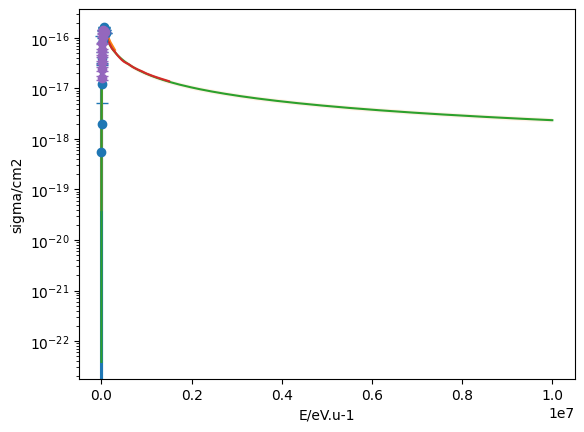

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
pycoll.plot_all_datasets(ax)

In [8]:
# Some basic dataset validation: e.g. abscissa values monotonically increasing,
# cross section values non-negative etc.
# First call validate()
pycoll.validate()
pycoll.all_valid

True

In [10]:
# Any validation messages will appear in the corresponding PyCollDataSet attribute:
for pk, ds in pycoll.datasets.items():
    print(pk, ds.validation_messages)

102737 []
107356 []
108169 []
103103 []
103104 []


In [14]:
# For example, introduce a deliberate error in the values of one DataSet:
ds = pycoll.datasets[108169]
ds.x[1] = ds.x[0]
ds.y[3] = -1
ds.validate()

False

In [15]:
ds.validation_messages

['x-data not monotonic!', 'y-data not non-negative!']

In [16]:
pycoll = PyCollision.get_datasets(query={'pks': [108456]})
print(pycoll)

<PyCollision object 1 datasets)>


In [17]:
ds = pycoll.datasets[108456]
ds

D108456: e- + Ni+7 → Ni+8 + 2e-

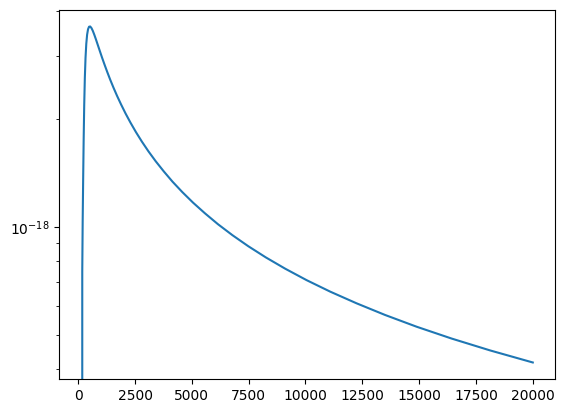

In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ds.plot_dataset(ax)